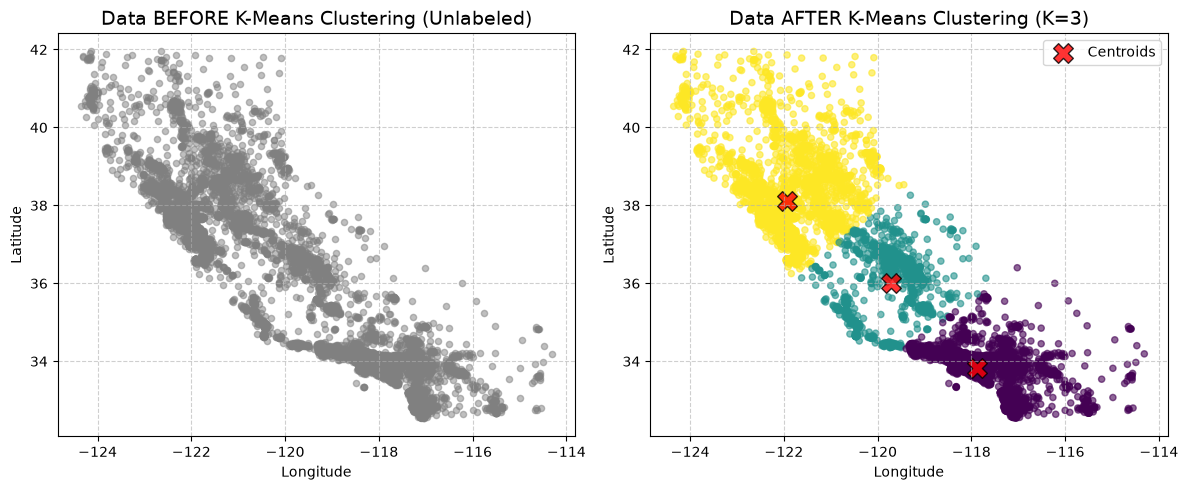


--- K-Means Results ---
The final coordinates of the 3 centroids are:
Cluster 0 Centroid: (Longitude=-117.89, Latitude=33.82)
Cluster 1 Centroid: (Longitude=-119.71, Latitude=36.00)
Cluster 2 Centroid: (Longitude=-121.93, Latitude=38.11)

Inertia (WCSS): 18287.02


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- 1. Data Loading ---
# Load the real housing dataset instead of synthetic blobs
df = pd.read_csv('housing.csv')

# Using longitude & latitude as the two features for clustering
# (this lets us see geographic clusters of houses)
X = df[['longitude', 'latitude']].values

K_clusters = 3
random_seed = 42

# --- 2. Visualization: Data BEFORE K-Means ---
plt.figure(figsize=(12, 5))

# Subplot 1: Unlabeled Data
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], s=20, c='gray', alpha=0.5)
plt.title('Data BEFORE K-Means Clustering (Unlabeled)', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.6)

# --- 3. K-Means Implementation ---
kmeans = KMeans(n_clusters=K_clusters, init='random', n_init='auto', random_state=random_seed)
kmeans.fit(X)

y_kmeans = kmeans.predict(X)          # Cluster label for each house
centers = kmeans.cluster_centers_     # Final centroid coordinates

# --- 4. Visualization: Data AFTER K-Means ---
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=20, cmap='viridis', alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, marker='X',
            edgecolor='black', label='Centroids')

plt.title(f'Data AFTER K-Means Clustering (K={K_clusters})', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('Housing_result.png', dpi=150)
plt.show()

# --- 5. Display Final Centroid Coordinates ---
print("\n--- K-Means Results ---")
print(f"The final coordinates of the {K_clusters} centroids are:")
for i, center in enumerate(centers):
    print(f"Cluster {i} Centroid: (Longitude={center[0]:.2f}, Latitude={center[1]:.2f})")
print(f"\nInertia (WCSS): {kmeans.inertia_:.2f}")
